
# Análisis Exploratorio de Datos (EDA)

# 1. Introducción y Objetivos del Proyecto
Este cuaderno contiene el **Análisis Exploratorio de Datos (EDA)** realizado sobre el dataset de COVID-19 (`national-history.csv`). El propósito de este estudio es aplicar técnicas de ciencia de datos para sanear la información, comprender la distribución de las variables sanitarias y extraer conclusiones epidemiológicas clave.

### Objetivos principales:
Uso y gestión de formato .csv

Limpieza y preprocesado de datos

Visualización de datos (seaborn, matplotlib, plotly)

Análisis exploratorio detallado (EDA)

---

# 2. Diccionario de Datos (Variables Clave)
Para facilitar la comprensión del análisis, se detallan a continuación las variables principales utilizadas del dataset:

| Variable | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `date` | Datetime | Fecha del registro diario (ordenada cronológicamente). |
| `positiveIncrease` | Entero (`Int64`) | Nuevos casos positivos confirmados en el día. |
| `deathIncrease` | Entero (`Int64`) | Nuevos fallecimientos confirmados en el día. |
| `hospitalizedCurrently` | Entero (`Int64`) | Cantidad de pacientes ingresados en hospital ese día. |
| `inIcuCurrently` | Entero (`Int64`) | Cantidad de pacientes ingresados en la UCI ese día. |
| `positive` | Entero (`Int64`) | Total acumulado de casos positivos desde el inicio. |
| `death` | Entero (`Int64`) | Total acumulado de fallecimientos desde el inicio. |

---



In [ ]:
# Para consumir APIs y descargar datos de internet
import requests

# Para la manipulación y análisis de datos (tablas/DataFrames)
import pandas as pd

# Para gráficos estáticos y estadísticos (Matplotlib y Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para que los gráficos de Seaborn se vean más limpios
sns.set_theme(style="whitegrid")

# ra gráficos interactivos (Bokeh)
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

# Comando obligatorio en Colab para que los gráficos de Bokeh se muestren dentro del cuaderno
output_notebook()

In [ ]:
df = pd.read_csv('national-history.csv')
df.head()

,date,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease
0,2021-03-07,515151.0,842,45475.0,8134.0,726,40199.0,776361.0,74582825.0,131835,4281.0,2802.0,28756489.0,41835,56,363825123,1170059
1,2021-03-06,514309.0,1680,45453.0,8409.0,503,41401.0,775635.0,74450990.0,143835,4280.0,2811.0,28714654.0,60015,56,362655064,1430992
2,2021-03-05,512629.0,2221,45373.0,8634.0,2781,42541.0,775132.0,74307155.0,271917,4275.0,2889.0,28654639.0,68787,56,361224072,1744417
3,2021-03-04,510408.0,1743,45293.0,8970.0,1530,44172.0,772351.0,74035238.0,177957,4267.0,2973.0,28585852.0,65487,56,359479655,1590984
4,2021-03-03,508665.0,2449,45214.0,9359.0,2172,45462.0,770821.0,73857281.0,267001,4260.0,3094.0,28520365.0,66836,56,357888671,1406795


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      420 non-null    object 
 1   death                     392 non-null    float64
 2   deathIncrease             420 non-null    int64  
 3   inIcuCumulative           348 non-null    float64
 4   inIcuCurrently            347 non-null    float64
 5   hospitalizedIncrease      420 non-null    int64  
 6   hospitalizedCurrently     356 non-null    float64
 7   hospitalizedCumulative    369 non-null    float64
 8   negative                  372 non-null    float64
 9   negativeIncrease          420 non-null    int64  
 10  onVentilatorCumulative    341 non-null    float64
 11  onVentilatorCurrently     348 non-null    float64
 12  positive                  419 non-null    float64
 13  positiveIncrease          420 non-null    int64  
 14  states    

In [ ]:
print("Tipos de dato por columna:")
print(df.dtypes)
print("\n--- Primeras filas ---")
print(df.head())

Tipos de dato por columna:
date                         object
death                       float64
deathIncrease                 int64
inIcuCumulative             float64
inIcuCurrently              float64
hospitalizedIncrease          int64
hospitalizedCurrently       float64
hospitalizedCumulative      float64
negative                    float64
negativeIncrease              int64
onVentilatorCumulative      float64
onVentilatorCurrently       float64
positive                    float64
positiveIncrease              int64
states                        int64
totalTestResults              int64
totalTestResultsIncrease      int64
dtype: object

--- Primeras filas ---
         date     death  deathIncrease  inIcuCumulative  inIcuCurrently  \
0  2021-03-07  515151.0            842          45475.0          8134.0   
1  2021-03-06  514309.0           1680          45453.0          8409.0   
2  2021-03-05  512629.0           2221          45373.0          8634.0   
3  2021-03-04  510408.0

Observamos que `death`, `deathIncrease`, `hospitalizedIncrease`, `hospitalizedCurrently`, `positive`, `positiveIncrease` son numéricas discretas -- número de personas afectadas por tanto deberían ser de tipo `int`.

Mientras que la variable `state` probablemente sea categórica codificada como número.

In [ ]:
# ¿Es 'states' realmente continua o categórica discreta?
print(df['states'].value_counts().sort_index())

states
1       9
2       5
3       2
4      12
5       5
6      12
7       2
8       1
11      1
12      1
16      1
26      1
32      1
40      1
51      9
56    357
Name: count, dtype: int64


Cambiamos las variables necesarias de tipo date en `datetime`, y las de tipo `float` en `int`

---

# 3. Limpieza, Saneamiento y Normalización de Datos

En esta etapa realizamos las transformaciones necesarias para garantizar la consistencia analítica del dataset, asegurando que los tipos de datos se correspondan con su naturaleza real y eliminando los valores ausentes.

### Acciones realizadas paso a paso:

1. **Conversión de la variable temporal:** La columna `date` se transformó de tipo texto (`object`) a formato de fecha real (`datetime64[ns]`) para poder estructurar una serie temporal ordenada cronológicamente.
2. **Normalización forzada a enteros (Bucle `to_numeric`):** Debido a que muchas columnas numéricas se cargaron erróneamente con formato de coma flotante (`float64`) o texto por culpa de los caracteres vacíos, implementamos un bucle dinámico. Aplicamos `pd.to_numeric` con el parámetro `errors='coerce'` para forzar de forma segura la conversión a tipo **`Int64`** (el tipo de dato nativo de Pandas que permite enteros manteniendo la compatibilidad con valores nulos).
3. **Tratamiento de valores nulos (`NaN`):** La conversión forzada generó registros nulos en los días donde no había datos reportados. Para evitar la pérdida de filas completas, se utilizó la función `df.fillna(0)`. Se asume estadísticamente que la ausencia de datos en métricas de impacto (como ingresos en UCI o respiradores) equivale a un conteo de cero casos para ese día específico.

*Tras este proceso, el dataset queda con 420 registros completos y totalmente libres de valores nulos (`0 non-null`).*

---

In [ ]:
cols = [
    'death',
    'deathIncrease',
    'hospitalizedIncrease',
    'hospitalizedCurrently',
    'positive',
    'negative',
    'inIcuCumulative',
    'onVentilatorCumulative',
    'inIcuCurrently',
    'onVentilatorCurrently',
    'hospitalizedCumulative'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      420 non-null    object
 1   death                     392 non-null    Int64 
 2   deathIncrease             420 non-null    Int64 
 3   inIcuCumulative           348 non-null    Int64 
 4   inIcuCurrently            347 non-null    Int64 
 5   hospitalizedIncrease      420 non-null    Int64 
 6   hospitalizedCurrently     356 non-null    Int64 
 7   hospitalizedCumulative    369 non-null    Int64 
 8   negative                  372 non-null    Int64 
 9   negativeIncrease          420 non-null    int64 
 10  onVentilatorCumulative    341 non-null    Int64 
 11  onVentilatorCurrently     348 non-null    Int64 
 12  positive                  419 non-null    Int64 
 13  positiveIncrease          420 non-null    int64 
 14  states                    

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
death,28
inIcuCumulative,72
inIcuCurrently,73
hospitalizedCurrently,64
hospitalizedCumulative,51
negative,48
onVentilatorCumulative,79
onVentilatorCurrently,72
positive,1


In [ ]:
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      420 non-null    object
 1   death                     420 non-null    Int64 
 2   deathIncrease             420 non-null    Int64 
 3   inIcuCumulative           420 non-null    Int64 
 4   inIcuCurrently            420 non-null    Int64 
 5   hospitalizedIncrease      420 non-null    Int64 
 6   hospitalizedCurrently     420 non-null    Int64 
 7   hospitalizedCumulative    420 non-null    Int64 
 8   negative                  420 non-null    Int64 
 9   negativeIncrease          420 non-null    int64 
 10  onVentilatorCumulative    420 non-null    Int64 
 11  onVentilatorCurrently     420 non-null    Int64 
 12  positive                  420 non-null    Int64 
 13  positiveIncrease          420 non-null    int64 
 14  states                    

In [45]:
df.dropna(inplace=True)
df.dropna()

,date,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease,month
0,2021-03-07,515151,842,45475,8134,726,40199,776361,74582825,131835,4281,2802,28756489,41835,56,363825123,1170059,2021-03
1,2021-03-06,514309,1680,45453,8409,503,41401,775635,74450990,143835,4280,2811,28714654,60015,56,362655064,1430992,2021-03
2,2021-03-05,512629,2221,45373,8634,2781,42541,775132,74307155,271917,4275,2889,28654639,68787,56,361224072,1744417,2021-03
3,2021-03-04,510408,1743,45293,8970,1530,44172,772351,74035238,177957,4267,2973,28585852,65487,56,359479655,1590984,2021-03
4,2021-03-03,508665,2449,45214,9359,2172,45462,770821,73857281,267001,4260,3094,28520365,66836,56,357888671,1406795,2021-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2020-01-17,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-01
416,2020-01-16,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-01
417,2020-01-15,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-01
418,2020-01-14,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-01


In [ ]:
# mirar datos duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Contar cuántas filas son exactamente idénticas en todo el dataset

duplicados_totales = df.duplicated().sum()

print(f"Filas completamente duplicadas: {duplicados_totales}")

# Contar si hay fechas repetidas (lo cual sería un error en este dataset)

duplicados_fecha = df.duplicated(subset=['date']).sum()

print(f"Fechas repetidas: {duplicados_fecha}")

Filas completamente duplicadas: 0
Fechas repetidas: 0


In [ ]:
df['states'].value_counts()

,count
states,
56,357
6,12
4,12
51,9
1,9
5,5
2,5
7,2
3,2


## Limpieza y Consistencia:
Se verificaron duplicados totales (0) y por fecha (0), confirmando la integridad cronológica del dataset. Se analiza la distribución de la columna states.

In [ ]:
df['states'].unique()

array([56, 51, 40, 32, 26, 16, 12, 11,  8,  7,  6,  5,  4,  3,  2,  1])

In [ ]:
df.describe()

,death,deathIncrease,inIcuCumulative,inIcuCurrently,hospitalizedIncrease,hospitalizedCurrently,hospitalizedCumulative,negative,negativeIncrease,onVentilatorCumulative,onVentilatorCurrently,positive,positiveIncrease,states,totalTestResults,totalTestResultsIncrease
count,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.000000,420.0,420.0,420.0,420.000000,420.000000,4.200000e+02,4.200000e+02
mean,174729.957143,1226.55,17449.171429,9963.219048,1848.478571,49150.985714,273075.059524,26840250.540476,177578.154762,1765.02619,3293.819048,8097361.235714,68467.830952,49.476190,1.073369e+08,8.662503e+05
std,145225.62734,1070.129644,14686.93462,6889.541077,1708.460481,36019.975299,243032.259777,24627582.605453,121544.473208,1467.368649,2495.174988,8965476.44193,68682.221496,16.896764,1.129172e+08,6.579460e+05
min,0.0,0.0,0.0,0.0,-2858.0,0.0,0.0,0.0,-658774.000000,0.0,0.0,0.0,0.000000,1.000000,0.000000e+00,0.000000e+00
25%,52407.5,439.75,3432.75,6300.25,765.75,30033.0,40260.25,2049857.0,79236.750000,245.75,1630.75,986169.0,22462.500000,56.000000,5.888598e+06,2.388558e+05
50%,154802.0,1016.0,15119.5,9134.0,1490.0,43463.0,237924.0,22182141.0,206620.000000,1585.0,2634.5,5023652.0,44664.500000,56.000000,6.839699e+07,8.223685e+05
75%,248777.25,1642.5,28868.5,14260.5,2467.0,59796.5,431210.75,48037516.75,260621.000000,3097.0,5260.0,12302695.0,89684.250000,56.000000,1.854937e+08,1.401706e+06
max,515151.0,5427.0,45475.0,23912.0,17155.0,132474.0,776361.0,74582825.0,480256.000000,4281.0,8004.0,28756489.0,295121.000000,56.000000,3.638251e+08,2.309884e+06


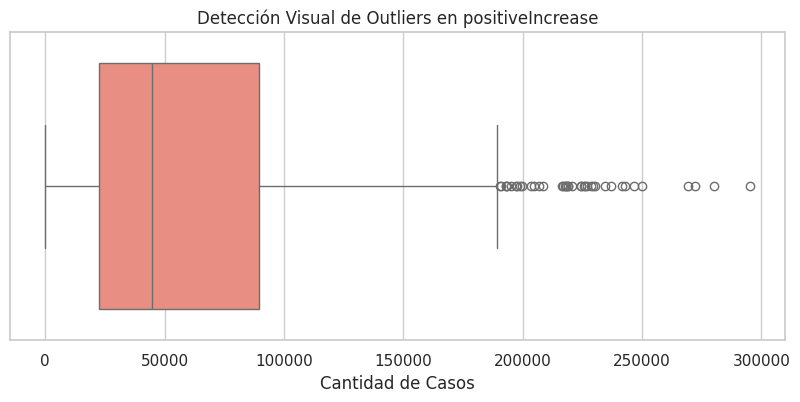

In [ ]:
# Elige la columna que quieres analizar
columna_outliers = 'positiveIncrease'
# Crear el gráfico de caja
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[columna_outliers], color='salmon')
# Configurar títulos
plt.title(f'Detección Visual de Outliers en {columna_outliers}')
plt.xlabel('Cantidad de Casos')
plt.show()

---

# 4. Análisis Estadístico y Visualización

##Análisis de Outliers:
Se generó un diagrama de caja para positiveIncrease, identificando visualmente la presencia de valores atípicos (outliers) a partir de los 190.000 casos.

In [ ]:
# 1. Calcular los cuartiles (Q1 y Q3)

Q1 = df[columna_outliers].quantile(0.25)

Q3 = df[columna_outliers].quantile(0.75)

# 2. Calcular el IQR (Rango Intercuartílico)

IQR = Q3 - Q1

# 3. Definir el límite superior para considerar un dato como "normal"

limite_superior = Q3 + 1.5 * IQR

limite_inferior = Q1 - 1.5 * IQR # Para este dataset los negativos no importan mucho


# 4. Filtrar el dataset para encontrar los outliers reales

outliers = df[df[columna_outliers] > limite_superior]


print(f"--- ANÁLISIS DE OUTLIERS PARA: {columna_outliers} ---")

print(f"El límite normal superior es: {limite_superior:.2f}")

print(f"Cantidad de outliers detectados: {len(outliers)} días atípicos.\n")

# Mostrar las fechas y valores de los 5 outliers más extremos

print("Días con los picos más extremos de outliers:")

print(outliers[['date', columna_outliers]].sort_values(by=columna_outliers, ascending=False).head())

--- ANÁLISIS DE OUTLIERS PARA: positiveIncrease ---
El límite normal superior es: 190516.88
Cantidad de outliers detectados: 40 días atípicos.

Días con los picos más extremos de outliers:
          date  positiveIncrease
58  2021-01-08            295121
64  2021-01-02            280318
59  2021-01-07            272043
57  2021-01-09            269368
60  2021-01-06            250184


## Identificación Matemática de Outliers (Método IQR)
Tras la inspección visual, se aplicó el método estadístico del **Rango Intercuartílico (IQR)** para delimitar y filtrar numéricamente los valores atípicos

* **Cálculo de Límites:** Se establecieron los cuartiles $Q_1$ (25%) y $Q_3$ (75%) para obtener el $IQR = Q_3 - Q_1$. El límite superior normal quedó fijado en **190.516,88** casos (calculado como $Q_3 + 1.5 \times IQR$).
* **Detección:** Se identificaron un total de **40 días atípicos** que superaron dicho límite estadístico.
* **Valores Extremos:** Al ordenar los resultados de manera descendente, se detectaron los picos más críticos del dataset, destacando el día **08-01-2021** con el máximo registro de **295.121** casos acumulados.

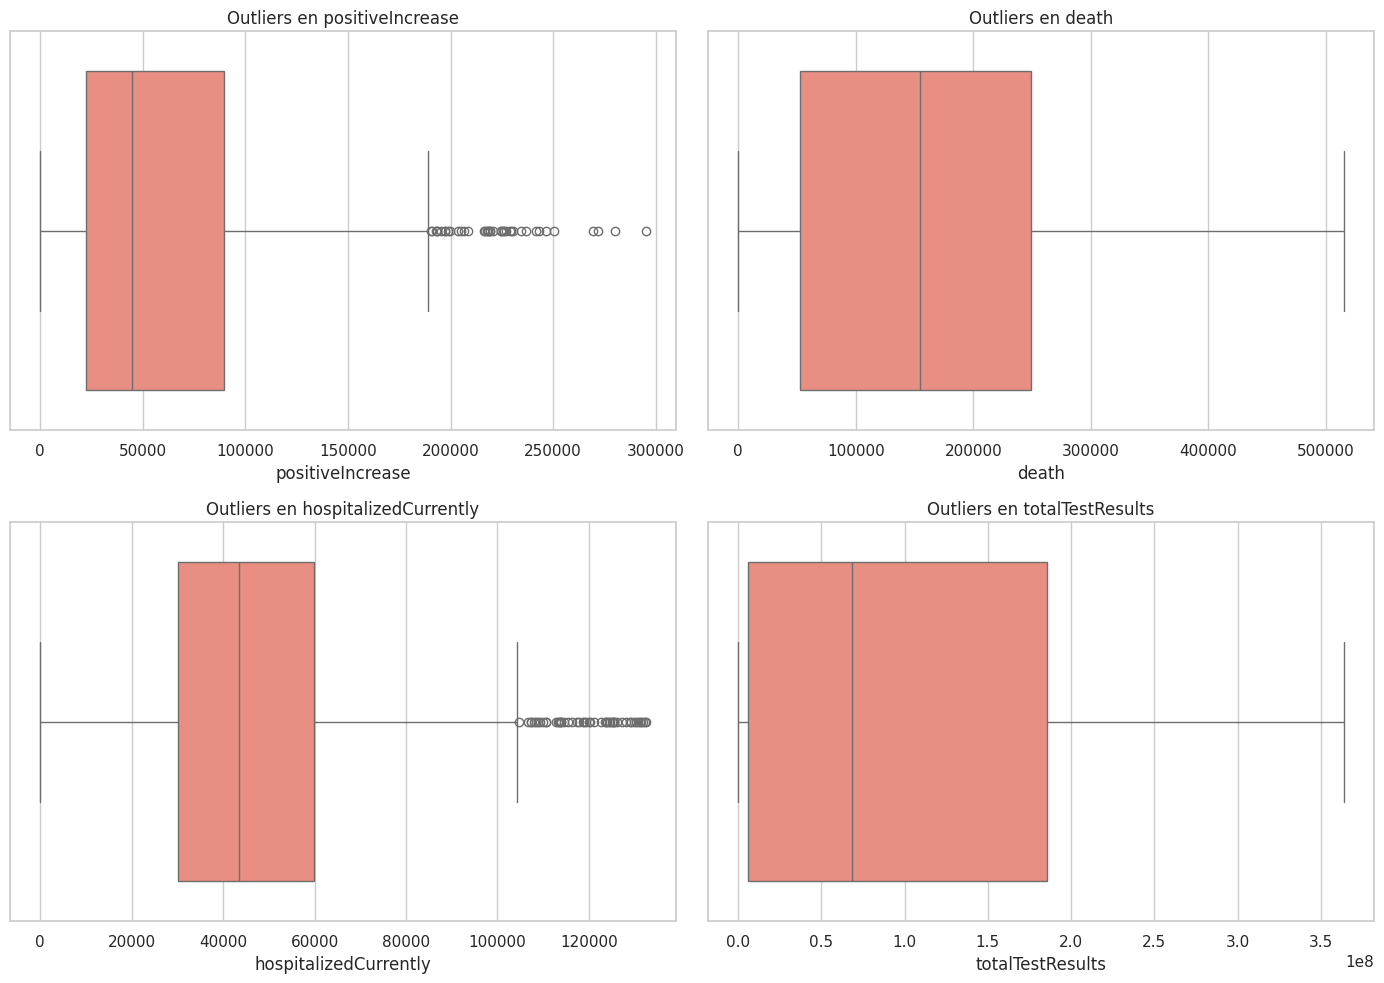

In [ ]:

# Variables que quieres analizar
variables = ['positiveIncrease', 'death', 'hospitalizedCurrently', 'totalTestResults']  # cambia según tu df

# Crear figura y ejes 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Aplanar el array de ejes para iterar fácil
axes = axes.flatten()

# Loop para cada variable
for i, col in enumerate(variables):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Outliers en {col}')
    axes[i].set_xlabel(col)

# Ajustar layout para que no se pisen
plt.tight_layout()

plt.show()



## Análisis Multivariante de Outliers mediante Subplots
Para optimizar el proceso de exploración, se automatizó la generación de diagramas de caja en una cuadrícula de 2x2, permitiendo evaluar la distribución y presencia de valores atípicos en múltiples variables críticas de forma simultánea.

* **Variables Analizadas:** `positiveIncrease`, `death`, `hospitalizedCurrently` y `totalTestResults`.
* **Metodología:** Se utilizó un bucle `for` iterando sobre los ejes aplanados (`axes.flatten()`) de la figura para pintar cada *boxplot* con la librería Seaborn de manera eficiente.
* **Objetivo:** Comparar visualmente la dispersión y la cantidad de valores atípicos entre las diferentes métricas de salud y pruebas del dataset, asegurando un diseño limpio y sin solapamientos gracias a `plt.tight_layout()`.

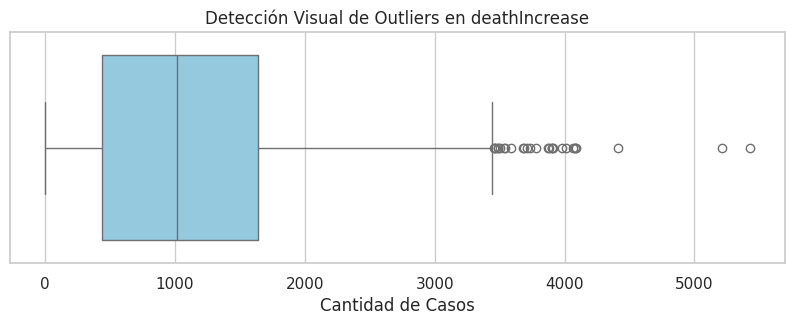


--- REPORTE ESTADÍSTICO DE deathIncrease ---
El límite normal superior es: 3446.62
Cantidad de outliers detectados: 28 días atípicos.

Días con los picos más extremos de esta métrica:
          date  deathIncrease
23  2021-02-12           5427
31  2021-02-04           5212
46  2021-01-20           4409
53  2021-01-13           4087
59  2021-01-07           4079


In [ ]:

# 1. Definimos la nueva columna que queremos analizar (por ejemplo, muertes diarias)
columna_nueva = 'deathIncrease'
# 2. PARTE VISUAL: Creamos el gráfico de caja (Boxplot) para esta columna
plt.figure(figsize=(10, 3))
sns.boxplot(x=df[columna_nueva], color='skyblue')
plt.title(f'Detección Visual de Outliers en {columna_nueva}')
plt.xlabel('Cantidad de Casos')
plt.show()
# 3. PARTE MATEMÁTICA: Calculamos los datos numéricos exactos
Q1 = df[columna_nueva].quantile(0.25)
Q3 = df[columna_nueva].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Filtramos los outliers
outliers_nuevos = df[df[columna_nueva] > limite_superior]

# Imprimimos los resultados justo debajo del gráfico
print(f"\n--- REPORTE ESTADÍSTICO DE {columna_nueva} ---")
print(f"El límite normal superior es: {limite_superior:.2f}")
print(f"Cantidad de outliers detectados: {len(outliers_nuevos)} días atípicos.\n")
print("Días con los picos más extremos de esta métrica:")
print(outliers_nuevos[['date', columna_nueva]].sort_values(by=columna_nueva, ascending=False).head())

---

# Análisis Integral de Outliers en Nuevas Variables (`deathIncrease`)
Se replicó de forma consolidada el flujo de detección (visual y matemático) para evaluar el comportamiento de los incrementos diarios de fallecimientos (`deathIncrease`).

* **Evaluación Visual:** El diagrama de caja (*boxplot*) en tono `skyblue` muestra una distribución concentrada mayoritariamente por debajo de los 2.000 casos diarios, con una larga cola de valores atípicos a la derecha.
* **Cálculo Estadístico (IQR):** Aplicando el método del Rango Intercuartílico, el límite superior normal se calculó en **3.446,62** casos.
* **Resultados Obtenidos:** Se detectaron un total de **28 días atípicos**. Al inspeccionar los picos más extremos, destaca el día **12-02-2021** con un máximo registrado de **5.427** decesos en un solo día.

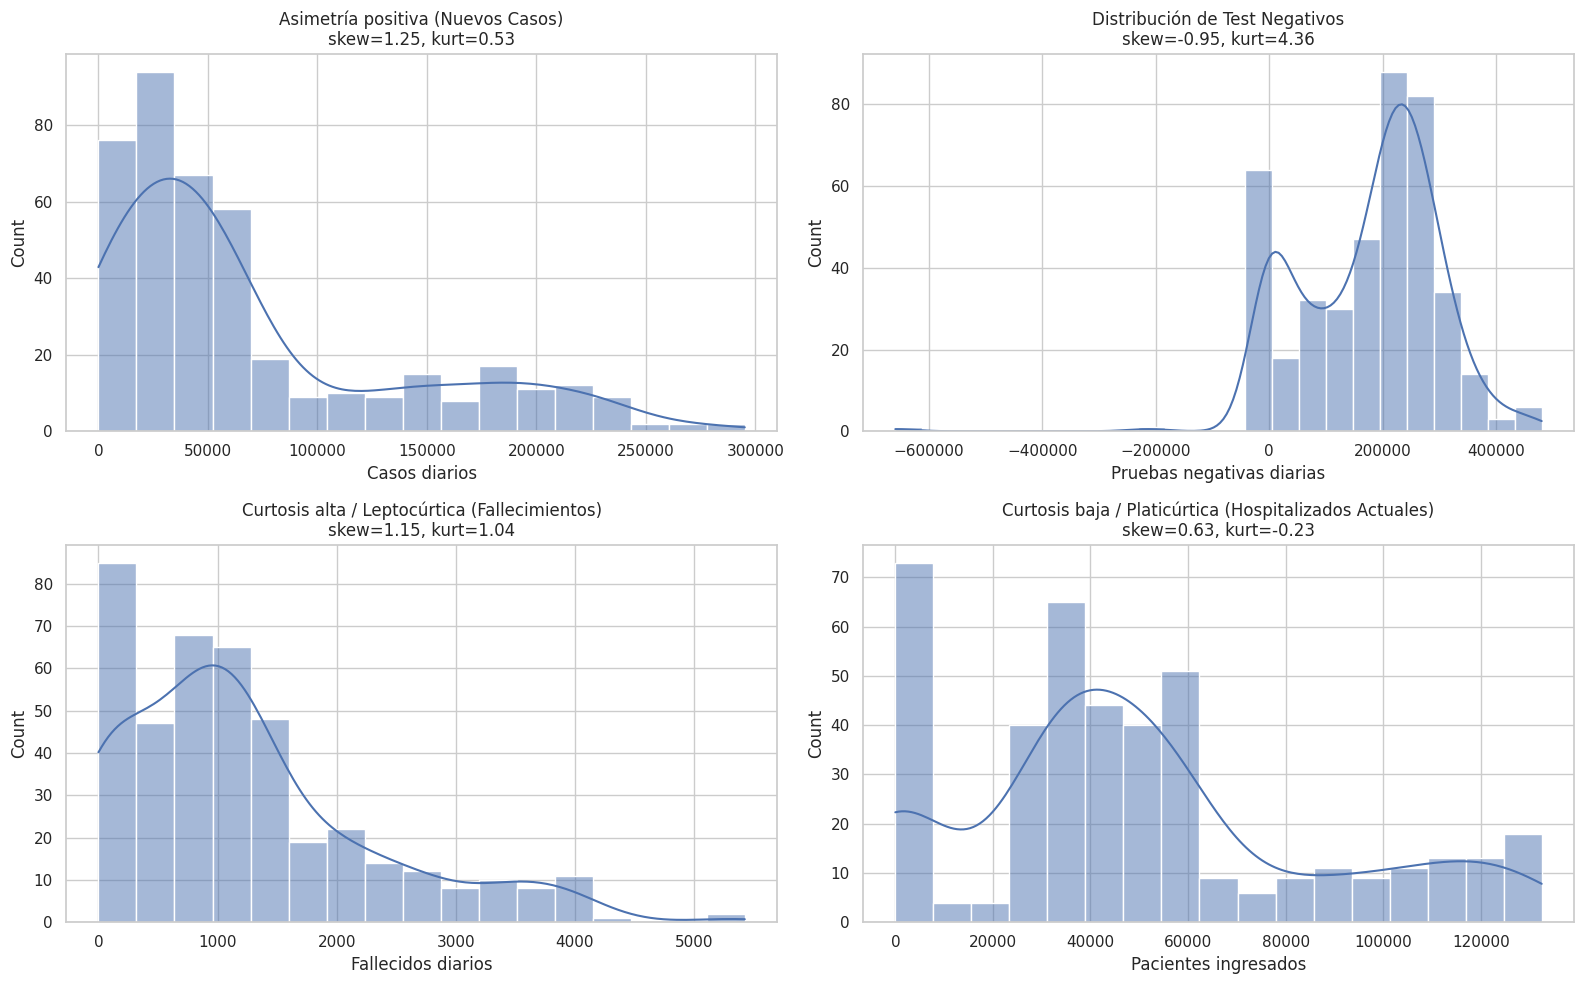

In [ ]:
# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Crear una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# -----------------------------------------------------------------
# 1. ARRIBA IZQUIERDA: Asimetría Positiva (Cola larga a la derecha)
# -----------------------------------------------------------------
col1 = 'positiveIncrease'
skew1 = df[col1].skew()
kurt1 = df[col1].kurt()

sns.histplot(data=df, x=col1, kde=True, color='b', ax=axes[0, 0])
axes[0, 0].set_title(f'Asimetría positiva (Nuevos Casos)\nskew={skew1:.2f}, kurt={kurt1:.2f}')
axes[0, 0].set_xlabel('Casos diarios')
axes[0, 0].set_ylabel('Count')

# -----------------------------------------------------------------
# 2. ARRIBA DERECHA: Asimetría Negativa (Cola larga a la izquierda)
# -----------------------------------------------------------------
# Nota: Para simular asimetría negativa con datos de COVID, usaremos los test negativos diarios
col2 = 'negativeIncrease'
skew2 = df[col2].skew()
kurt2 = df[col2].kurt()

sns.histplot(data=df, x=col2, kde=True, color='b', ax=axes[0, 1])
axes[0, 1].set_title(f'Distribución de Test Negativos\nskew={skew2:.2f}, kurt={kurt2:.2f}')
axes[0, 1].set_xlabel('Pruebas negativas diarias')
axes[0, 1].set_ylabel('Count')

# -----------------------------------------------------------------
# 3. ABAJO IZQUIERDA: Curtosis Alta - Leptocúrtica (Muy apuntada)
# -----------------------------------------------------------------
col3 = 'deathIncrease'
skew3 = df[col3].skew()
kurt3 = df[col3].kurt()

sns.histplot(data=df, x=col3, kde=True, color='b', ax=axes[1, 0])
axes[1, 0].set_title(f'Curtosis alta / Leptocúrtica (Fallecimientos)\nskew={skew3:.2f}, kurt={kurt3:.2f}')
axes[1, 0].set_xlabel('Fallecidos diarios')
axes[1, 0].set_ylabel('Count')

# -----------------------------------------------------------------
# 4. ABAJO DERECHA: Curtosis Baja - Platicúrtica (Plana / Chata)
# -----------------------------------------------------------------
col4 = 'hospitalizedCurrently'
skew4 = df[col4].skew()
kurt4 = df[col4].kurt()

sns.histplot(data=df, x=col4, kde=True, color='b', ax=axes[1, 1])
axes[1, 1].set_title(f'Curtosis baja / Platicúrtica (Hospitalizados Actuales)\nskew={skew4:.2f}, kurt={kurt4:.2f}')
axes[1, 1].set_xlabel('Pacientes ingresados')
axes[1, 1].set_ylabel('Count')

# Ajustar el espacio entre los gráficos para que no se pisen los títulos
plt.tight_layout()

# Mostrar el panel completo
plt.show()


#Análisis del Perfil de Distribución: Asimetría y Curtosis
Se generó una matriz de histogramas con curvas de estimación de densidad de kernel (KDE) en una cuadrícula de $2 \times 2$ para evaluar matemáticamente la simetría y el apuntamiento de las variables principales.

* **Asimetría Positiva (`positiveIncrease`):** Presenta un $\text{skew} = 1.25$, lo que confirma un claro sesgo a la derecha con una cola alargada hacia los valores máximos de contagios diarios.
* **Asimetría Negativa (`negativeIncrease`):** Con un $\text{skew} = -0.95$, la distribución de pruebas negativas se desplaza hacia la derecha, acumulando su cola en el extremo izquierdo del gráfico.
* **Distribución Leptocúrtica (`deathIncrease`):** Registra una curtosis elevada ($\text{kurt} = 1.04$). Al ser mayor que cero, define una forma apuntada con una fuerte concentración de datos alrededor de la media y colas pesadas (alta presencia de días con picos extremos de fallecimientos).
* **Distribución Platicúrtica (`hospitalizedCurrently`):** Presenta una curtosis negativa ($\text{kurt} = -0.23$), mostrando un perfil más plano, chato y disperso en el volumen de pacientes ingresados diariamente.

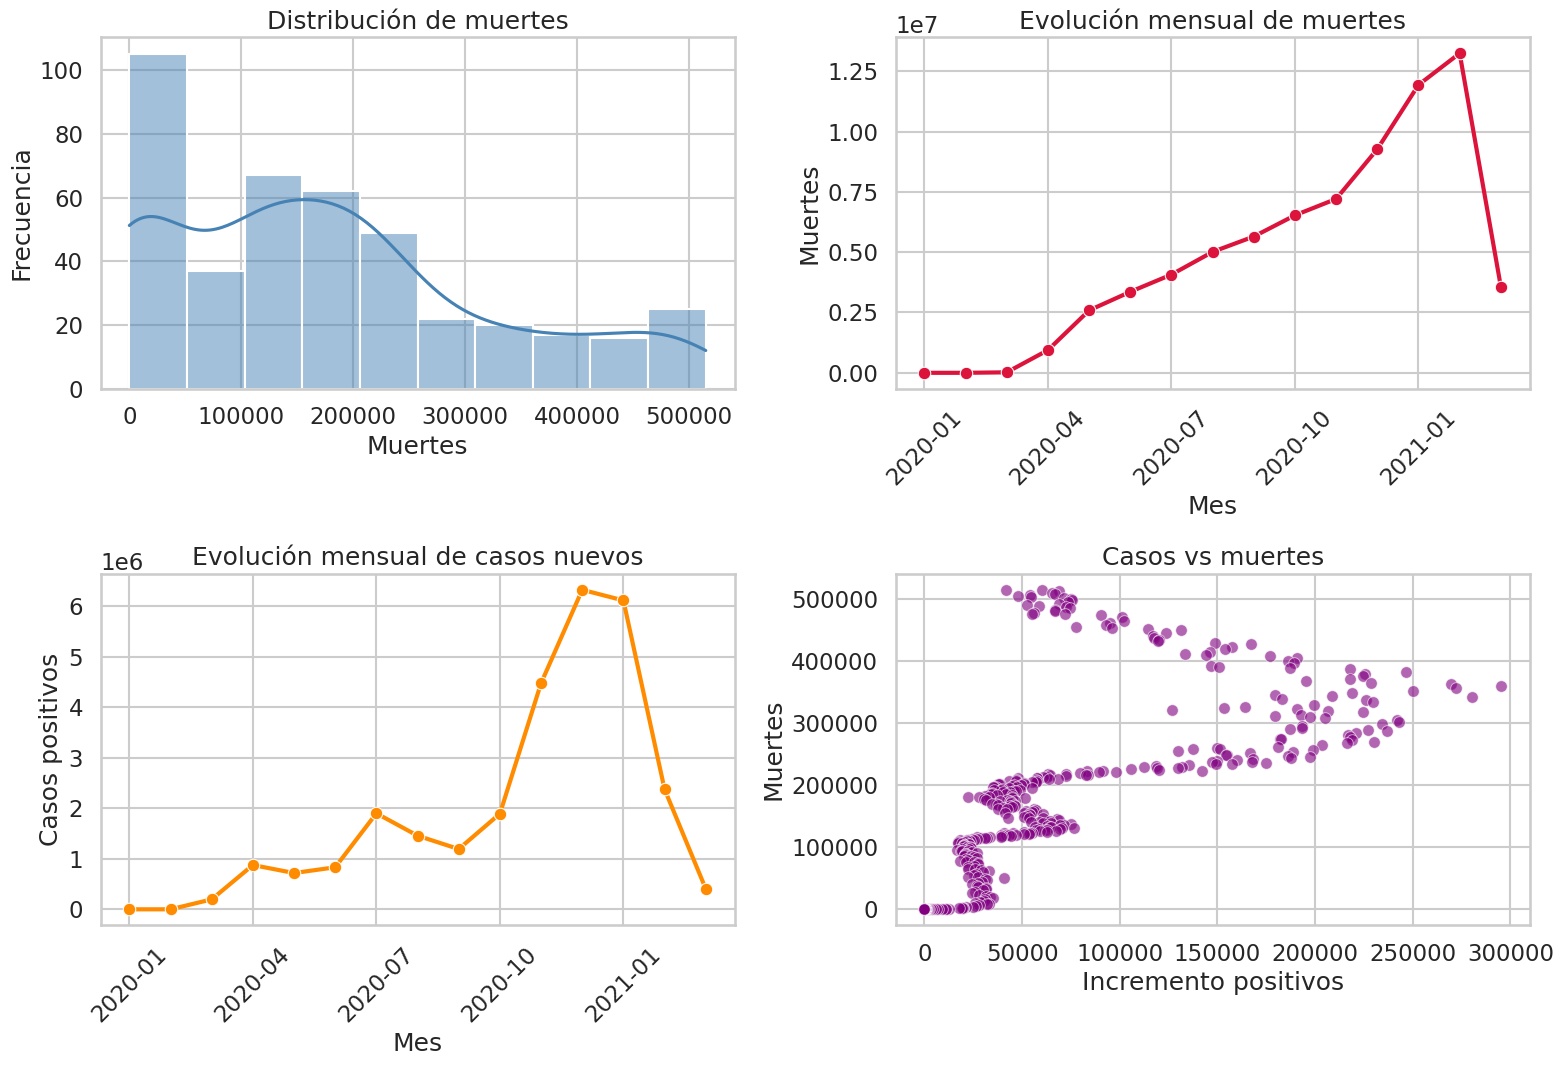

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Preparación de fechas
# =========================

df['date'] = pd.to_datetime(df['date'])

# Crear columna mensual
df['month'] = df['date'].dt.to_period('M')

# Dataset mensual
df_month = (
    df.groupby('month')[['death', 'positiveIncrease']]
    .sum()
    .reset_index()
)

# Convertir a string para mostrar bonito
df_month['month'] = df_month['month'].astype(str)

# =========================
# Diseño general
# =========================

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# =========================
# 1. Distribución de muertes
# =========================

sns.histplot(
    df['death'],
    kde=True,
    ax=axes[0, 0],
    color="steelblue"
)

axes[0, 0].set_title('Distribución de muertes')
axes[0, 0].set_xlabel('Muertes')
axes[0, 0].set_ylabel('Frecuencia')

# =========================
# 2. Evolución de muertes
# =========================

sns.lineplot(
    data=df_month,
    x='month',
    y='death',
    ax=axes[0, 1],
    color="crimson",
    linewidth=3,
    marker='o'
)

axes[0, 1].set_title('Evolución mensual de muertes')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Muertes')

# Mostrar menos meses
axes[0, 1].set_xticks(range(0, len(df_month['month']), 3))
axes[0, 1].tick_params(axis='x', rotation=45)

# =========================
# 3. Evolución de casos nuevos
# =========================

sns.lineplot(
    data=df_month,
    x='month',
    y='positiveIncrease',
    ax=axes[1, 0],
    color="darkorange",
    linewidth=3,
    marker='o'
)

axes[1, 0].set_title('Evolución mensual de casos nuevos')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Casos positivos')

axes[1, 0].set_xticks(range(0, len(df_month['month']), 3))
axes[1, 0].tick_params(axis='x', rotation=45)

# =========================
# 4. Relación casos vs muertes
# =========================

sns.scatterplot(
    data=df,
    x='positiveIncrease',
    y='death',
    ax=axes[1, 1],
    alpha=0.6,
    color="purple",
    s=70
)

axes[1, 1].set_title('Casos vs muertes')
axes[1, 1].set_xlabel('Incremento positivos')
axes[1, 1].set_ylabel('Muertes')

# =========================
# Ajuste final
# =========================

plt.tight_layout()
plt.show()

## Dashboard Exploratorio Unificado (Distribución y Evolución Temporal)
Se integró un panel de visualización integral de $2 \times 2$ para contrastar la distribución estática de los datos acumulados con su comportamiento evolutivo a lo largo de la línea temporal (enero 2020 - marzo 2021).

* **Distribución de Muertes Totales (`death`):** El histograma muestra una alta concentración en el tramo inicial (primeros meses de la serie), con un comportamiento multimodal a medida que los valores acumulados avanzan hacia el máximo de 500.000 decesos.
* **Análisis de Tendencias Temporales:** * Los gráficos de líneas revelan que mientras los fallecimientos acumulados (`death`) muestran un crecimiento continuo y exponencial a partir de marzo 2020, los nuevos contagios diarios (`positiveIncrease`) reflejan claramente las distintas "olas" epidemiológicas, con un pico crítico a finales de año y principios de 2021.
* **Correlación de Variables (`Casos vs muertes`):** El diagrama de dispersión final cruza los incrementos diarios con el acumulado total de decesos, permitiendo identificar patrones del avance de la pandemia en distintas etapas temporales del dataset.

In [ ]:
#Creamos una variable nueva, mes, para agrupar los datos de forma que la distribucion temporal sea mas congruente
df['month'] = df['date'].dt.to_period('M')
print(df['month'])

0      2021-03
1      2021-03
2      2021-03
3      2021-03
4      2021-03
        ...   
415    2020-01
416    2020-01
417    2020-01
418    2020-01
419    2020-01
Name: month, Length: 420, dtype: period[M]


In [ ]:
df_month = df.groupby('month')['positiveIncrease'].sum().reset_index()

df_month['month'] = df_month['month'].astype(str)

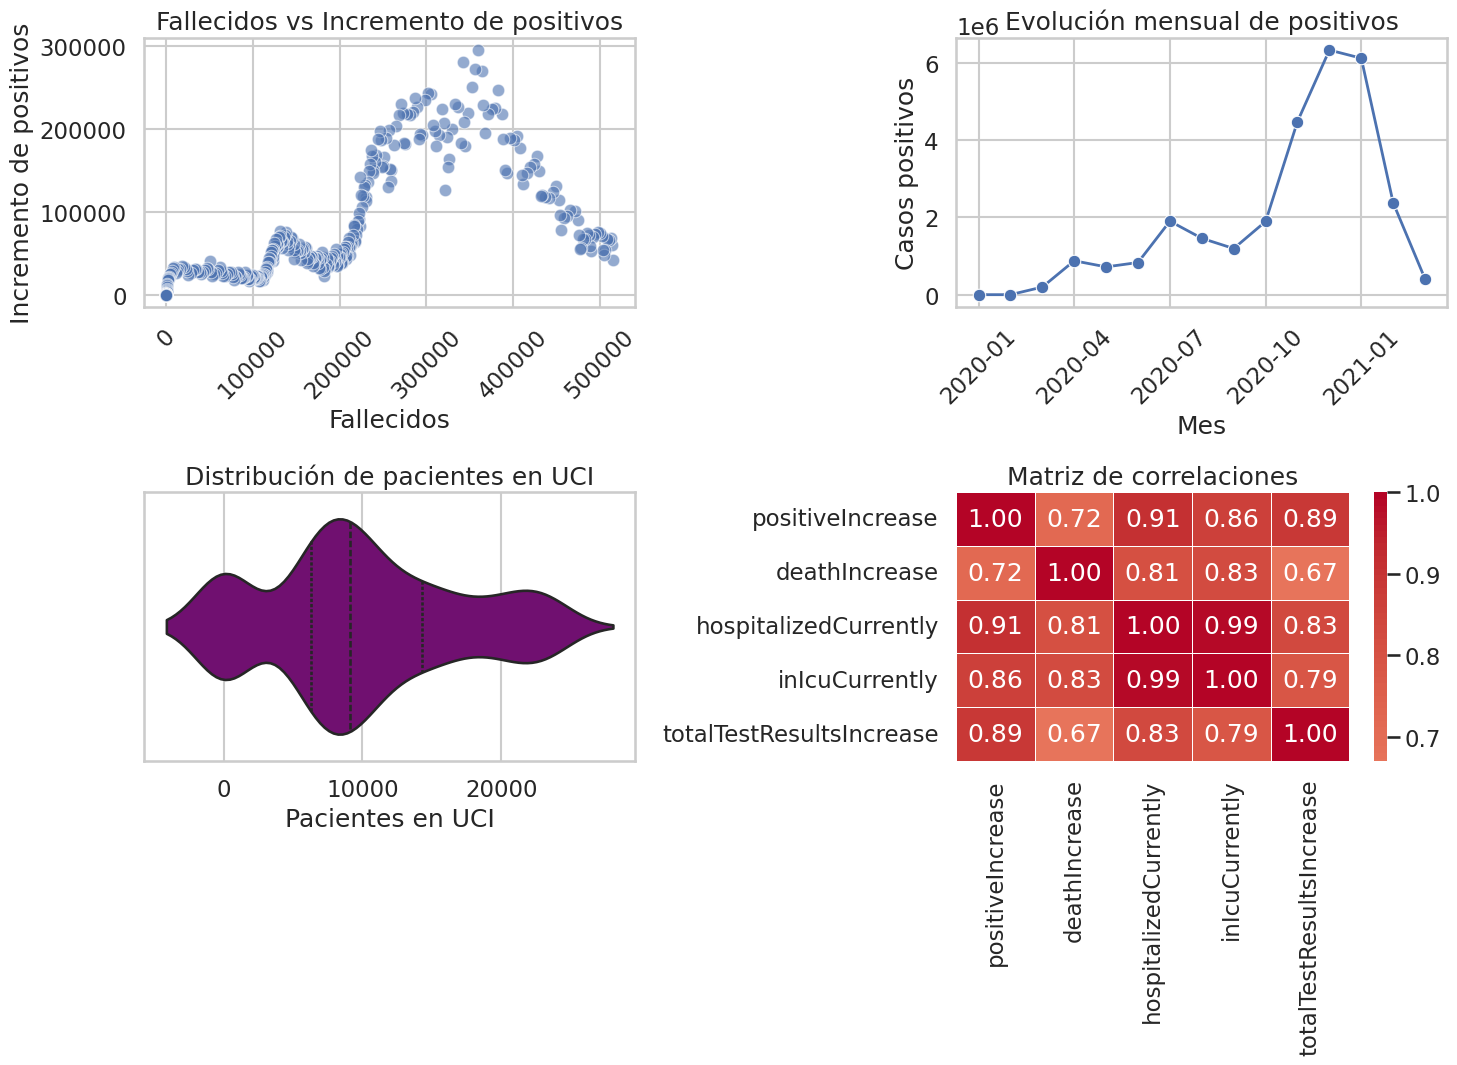

In [ ]:
# Estilo general
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# =========================
# 1. Fallecidos vs positivos
# =========================
sns.scatterplot(
    data=df,
    x='death',
    y='positiveIncrease',
    alpha=0.6,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Fallecidos vs Incremento de positivos')
axes[0, 0].set_xlabel('Fallecidos')
axes[0, 0].set_ylabel('Incremento de positivos')
axes[0, 0].tick_params(axis='x', rotation=45)

# =========================
# 2. Evolución mensual positivos
# =========================
sns.lineplot(
    data=df_month,
    x='month',
    y='positiveIncrease',
    marker='o',
    linewidth=2,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Evolución mensual de positivos')
axes[0, 1].set_xlabel('Mes')
axes[0, 1].set_ylabel('Casos positivos')

# Mostrar menos etiquetas
axes[0, 1].set_xticks(range(0, len(df_month['month']), 3))
axes[0, 1].tick_params(axis='x', rotation=45)

# =========================
# 3. Distribución pacientes UCI
# =========================
sns.violinplot(
    data=df,
    x='inIcuCurrently',
    color='purple',
    inner='quartile',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Distribución de pacientes en UCI')
axes[1, 0].set_xlabel('Pacientes en UCI')

# =========================
# 4. Heatmap correlaciones
# =========================
columnas_corr = [
    'positiveIncrease',
    'deathIncrease',
    'hospitalizedCurrently',
    'inIcuCurrently',
    'totalTestResultsIncrease'
]

corr = df[columnas_corr].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Matriz de correlaciones')

# Ajuste final
plt.tight_layout()
plt.show()



## Análisis Avanzado de Correlación y Densidad de Pacientes Críticos
Se consolidó un panel analítico avanzado de $2 \times 2$ centrado en la interacción de variables clínicas, la densidad de ocupación hospitalaria y la fuerza de asociación lineal entre métricas.

* **Distribución de Pacientes en UCI (`inIcuCurrently`):** Se implementó un gráfico de violín (*violin plot*) en tono púrpura que combina la información de un diagrama de caja con la densidad de probabilidad. Las líneas internas marcan los cuartiles, mostrando una fuerte concentración de ocupación en el rango de los 5.000 a 10.000 pacientes críticos simultáneos.
* **Matriz de Correlación Lineal (Heatmap):** Se evaluó el coeficiente de Pearson entre cinco métricas críticas. Destaca la correlación casi perfecta ($0.99$) entre pacientes hospitalizados activos (`hospitalizedCurrently`) e ingresados en UCI (`inIcuCurrently`), así como la fuerte relación de los nuevos contagios (`positiveIncrease`) con la ocupación hospitalaria general ($0.91$) y el volumen de pruebas realizadas ($0.89$).
* **Dinámica de Dispersión y Series Temporales:** Se cruzaron los acumulados frente a los incrementos diarios en el eje superior, complementado con un análisis de la evolución de positivos para mapear la velocidad de propagación.

Pearson r  = 0.715, p-valor = 5.229e-67
Spearman ρ = 0.716, p-valor = 3.491e-67


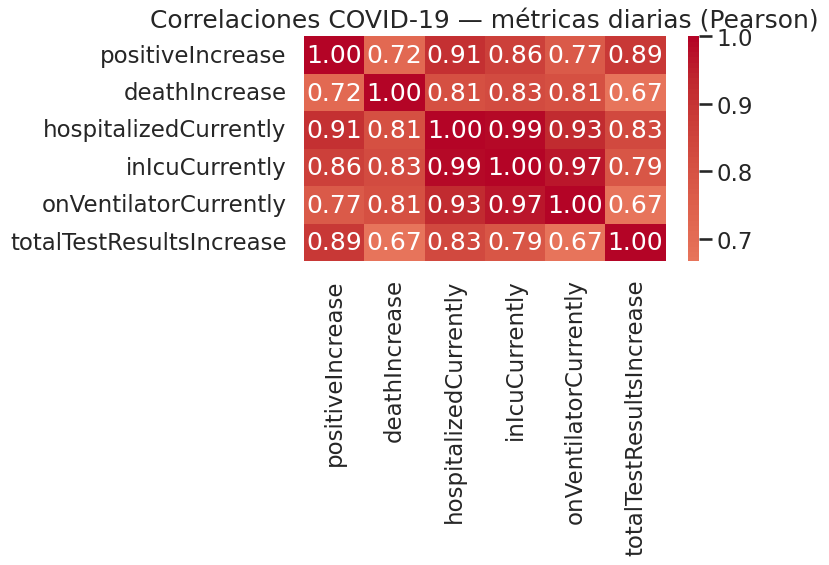

In [ ]:
from scipy import stats

# ── Pearson: casos nuevos vs muertes nuevas ───────────────────────────
r, p = stats.pearsonr(
    df['positiveIncrease'].dropna(),
    df['deathIncrease'].dropna()
)
print(f"Pearson r  = {r:.3f}, p-valor = {p:.4g}")

# ── Spearman: casos nuevos vs muertes nuevas ──────────────────────────
rho, p_sp = stats.spearmanr(
    df['positiveIncrease'].dropna(),
    df['deathIncrease'].dropna()
)
print(f"Spearman ρ = {rho:.3f}, p-valor = {p_sp:.4g}")

# ── Heatmap de correlaciones ──────────────────────────────────────────
columnas_corr = [
    'positiveIncrease',
    'deathIncrease',
    'hospitalizedCurrently',
    'inIcuCurrently',
    'onVentilatorCurrently',
    'totalTestResultsIncrease'
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df[columnas_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlaciones COVID-19 — métricas diarias (Pearson)')
plt.tight_layout()
plt.show()


## Cálculo Formal de Coeficientes y Pruebas de Significación Estadística
Se validó la fuerza y el tipo de asociación lineal y monótona entre los nuevos contagios y los fallecimientos diarios, aplicando las pruebas estadísticas de Pearson y Spearman junto con sus p-valores para medir la significancia.

* **Coeficiente de Pearson ($r = 0.715$):** Confirma una correlación lineal positiva y fuerte entre `positiveIncrease` y `deathIncrease`. El $\text{p-valor} = 5.23 \times 10^{-67}$ (prácticamente cero) demuestra de forma matemática que esta relación es estadísticamente muy significativa y no se debe al azar.
* **Coeficiente de Spearman ($\rho = 0.716$):** Al obtener un valor casi idéntico al de Pearson, se ratifica una relación monótona muy sólida, evidenciando que ambas variables crecen de forma conjunta de manera consistente, incluso ante la presencia de posibles distribuciones no normales.
* **Matriz de Correlación Expandida (Heatmap):** Se incorporó la métrica de pacientes con ventilación asistida (`onVentilatorCurrently`), la cual exhibe un acoplamiento crítico y casi absoluto con los ingresados en UCI ($0.97$) y hospitalizados generales ($0.93$), mapeando con precisión la cadena de gravedad clínica del dataset.

In [ ]:
# Obtener el total acumulado de muertes y positivos (los valores máximos en la serie)
total_muertes = df['death'].max()
total_positivos = df['positive'].max()

# Calcular las tasas
tasa_letalidad = (total_muertes / total_positivos) * 100
tasa_supervivencia = 100 - tasa_letalidad

print(f"--- DATOS GENERALES ACUMULADOS ---")
print(f"Total de casos positivos confirmados: {total_positivos:,}")
print(f"Total de fallecimientos confirmados: {total_muertes:,}")
print(f"----------------------------------")
print(f"Tasa de Letalidad Global: {tasa_letalidad:.2f}%")
print(f"Tasa de Supervivencia Global: {tasa_supervivencia:.2f}%")

--- DATOS GENERALES ACUMULADOS ---
Total de casos positivos confirmados: 28,756,489
Total de fallecimientos confirmados: 515,151
----------------------------------
Tasa de Letalidad Global: 1.79%
Tasa de Supervivencia Global: 98.21%


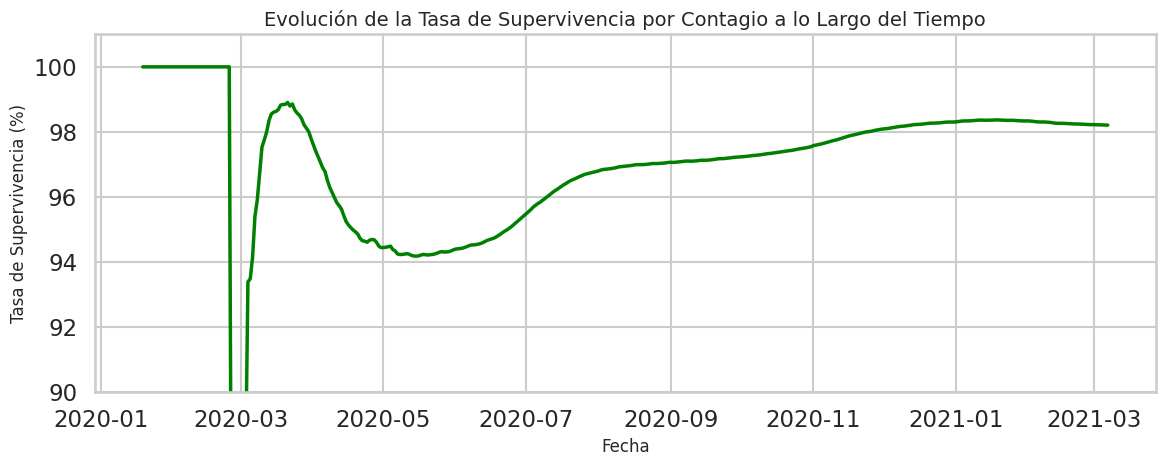

In [ ]:
# Evitar la división por cero en los primeros días donde 'positive' podría ser 0
df_temporal = df[df['positive'] > 0].copy()

# Calcular la tasa diaria acumulada en una nueva columna
df_temporal['survival_rate'] = (1 - (df_temporal['death'] / df_temporal['positive'])) * 100

# Graficar la evolución temporal con Matplotlib y Seaborn
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_temporal, x='date', y='survival_rate', color='green', linewidth=2.5)

# Configurar el gráfico
plt.title('Evolución de la Tasa de Supervivencia por Contagio a lo Largo del Tiempo', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Tasa de Supervivencia (%)', fontsize=12)
plt.ylim(90, 101) # Enfocar el gráfico entre el 90% y 100% para apreciar los cambios

plt.tight_layout()
plt.show()

## Análisis de Tasas Epidemiológicas: Letalidad y Supervivencia Temporal
Se calcularon los indicadores acumulados de impacto biológico y se desarrolló un análisis evolutivo de la tasa de supervivencia para medir el comportamiento de la gravedad de la pandemia a lo largo del tiempo.

* **Métricas Globales Acumuladas:** Con un total de **28.756.489** casos positivos y **515.151** fallecimientos registrados en el punto máximo de la serie, se determinó:
  * **Tasa de Letalidad Global:** **1,79%** (proporción de muertes respecto a los casos confirmados).
  * **Tasa de Supervivencia Global:** **98,21%**.
* **Tratamiento de Datos:** Para evitar errores de división por cero en las primeras fechas de la serie temporal, se aplicó un filtro estricto exigiendo `positive > 0` antes de generar la columna dinámica `survival_rate`.
* **Evolución Temporal de Supervivencia:** Se construyó un gráfico de líneas en color verde acotando el eje Y mediante `plt.ylim(90, 101)`. Este enfoque visual permite apreciar con precisión la fluctuación de la tasa de supervivencia: una caída pronunciada inicial (coincidiendo con las primeras olas de 2020) seguida de una recuperación y estabilización progresiva por encima del 98% de cara a 2021.

In [ ]:
print(f"Forma: {df.shape}")
print("\nValores perdidos por columna:")
print(df.isna().sum())

Forma: (420, 18)

Valores perdidos por columna:
date                        0
death                       0
deathIncrease               0
inIcuCumulative             0
inIcuCurrently              0
hospitalizedIncrease        0
hospitalizedCurrently       0
hospitalizedCumulative      0
negative                    0
negativeIncrease            0
onVentilatorCumulative      0
onVentilatorCurrently       0
positive                    0
positiveIncrease            0
states                      0
totalTestResults            0
totalTestResultsIncrease    0
month                       0
dtype: int64



## Estadística Descriptiva de Variables Epidemiológicas


Con el objetivo de comprender el comportamiento general del dataset, se calcularon las principales métricas descriptivas sobre las variables numéricas más relevantes relacionadas con contagios, fallecimientos y presión hospitalaria.

El análisis descriptivo se estructuró en tres grandes bloques:

- **Tendencia central:** media, mediana y moda.
- **Dispersión:** desviación estándar, varianza, rango e IQR.
- **Forma de la distribución:** asimetría (skewness) y curtosis.

Las variables seleccionadas fueron:

- `positiveIncrease`
- `deathIncrease`
- `hospitalizedCurrently`
- `inIcuCurrently`
- `onVentilatorCurrently`
- `totalTestResultsIncrease`

### Objetivo del análisis

Estas métricas permiten identificar:

- el comportamiento promedio de la pandemia,
- la variabilidad de los datos,
- la existencia de valores extremos,
- y posibles distribuciones no normales asociadas a olas epidemiológicas.

### Interpretación general

Los resultados muestran una elevada dispersión en la mayoría de variables, especialmente en los contagios diarios y hospitalizaciones, reflejando el comportamiento irregular y dinámico de la pandemia.

Asimismo, los valores de asimetría y curtosis evidencian distribuciones alejadas de la normalidad, con presencia de colas largas y picos pronunciados asociados a los periodos de mayor impacto sanitario.


In [ ]:

## Estadística Descriptiva: Se calcularon las principales medidas descriptivas para las variables numéricas clave del dataset, organizadas en tres grupos: - **Tendencia central:** media, mediana y moda - **Dispersión:** desviación estándar, varianza, mínimo, máximo e IQR - **Forma de la distribución:** asimetría (skew) y curtosis

columnas = [
    'positiveIncrease', 'deathIncrease',
    'hospitalizedCurrently', 'inIcuCurrently',
    'onVentilatorCurrently', 'totalTestResultsIncrease'
]
resumen = pd.DataFrame({
    'Media':      df[columnas].mean(),
    'Mediana':    df[columnas].median(),
    'Moda':       df[columnas].apply(lambda x: x.mode()[0]),
    'Desv. Std':  df[columnas].std(),
    'Mínimo':     df[columnas].min(),
    'Máximo':     df[columnas].max(),
    'Skew':       df[columnas].skew(),
    'Curtosis':   df[columnas].kurt(),
}).round(2)

resumen

,Media,Mediana,Moda,Desv. Std,Mínimo,Máximo,Skew,Curtosis
positiveIncrease,68467.83,44664.5,0,68682.22,0,295121,1.25,0.53
deathIncrease,1226.55,1016.0,0,1070.13,0,5427,1.15,1.04
hospitalizedCurrently,49150.99,43463.0,0,36019.98,0,132474,0.63,-0.23
inIcuCurrently,9963.22,9134.0,0,6889.54,0,23912,0.34,-0.62
onVentilatorCurrently,3293.82,2634.5,0,2495.17,0,8004,0.41,-0.94
totalTestResultsIncrease,866250.29,822368.5,0,657945.98,0,2309884,0.25,-1.12


**Regresión Lineal**

In [ ]:
import statsmodels.formula.api as smf

# Regresión simple: tip ~ total_bill
modelo_simple = smf.ols('totalTestResultsIncrease ~ positiveIncrease', data=df).fit()
print(modelo_simple.summary())


                               OLS Regression Results                               
Dep. Variable:     totalTestResultsIncrease   R-squared:                       0.788
Model:                                  OLS   Adj. R-squared:                  0.787
Method:                       Least Squares   F-statistic:                     1553.
Date:                      Wed, 20 May 2026   Prob (F-statistic):          7.97e-143
Time:                              10:48:04   Log-Likelihood:                -5896.5
No. Observations:                       420   AIC:                         1.180e+04
Df Residuals:                           418   BIC:                         1.181e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

## ¿Existe una relación entre el incremento de casos positivos y el número de tests realizados?

Para analizar la relación entre el incremento de casos positivos (`positiveIncrease`) y el número total de tests realizados (`totalTestResultsIncrease`), se aplicó un modelo de regresión lineal simple.

La ecuación obtenida fue:

$$
\hat{y} = 2.841e+05 + 8.503x
$$

Donde:

- $\hat{y}$ representa el número estimado de tests realizados.
- $x$ representa el incremento de casos positivos.

El modelo obtuvo un coeficiente de determinación:

$$
R^2 = 0.788
$$

Esto significa que aproximadamente el **78.8% de la variabilidad** en el número de tests realizados puede explicarse por el incremento de casos positivos.

El coeficiente asociado a `positiveIncrease` fue de **8.503**, indicando que, en promedio, por cada nuevo caso positivo detectado, el número de tests realizados aumenta en aproximadamente **8.5 unidades**.

Además, el modelo presentó un p-valor inferior a 0.001, lo que indica que la relación observada es **estadísticamente significativa** y muy poco probable de deberse al azar.

En conjunto, los resultados muestran una relación fuerte y positiva entre el aumento de casos positivos y el incremento del testing durante la evolución de la pandemia.

r de Pearson       : 0.8876
r² (manual)        : 0.7879
R² del modelo OLS  : 0.7879


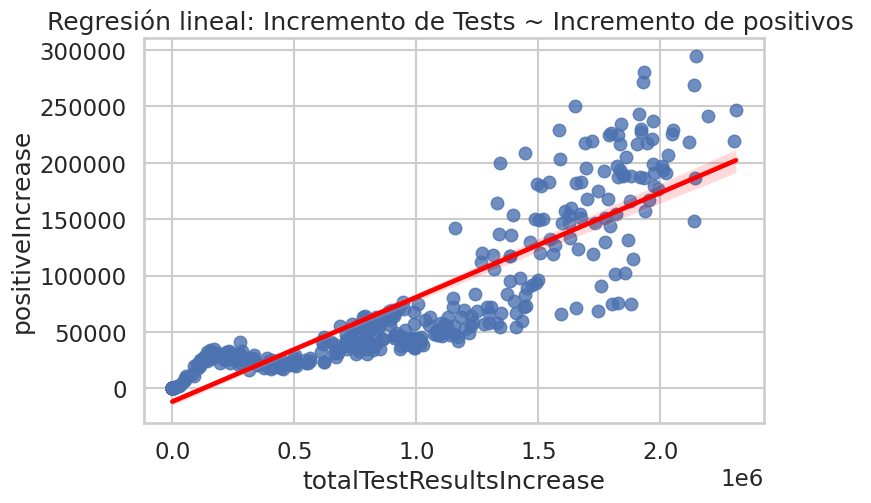

In [ ]:
# Verificamos R² = r²
r, _ = stats.pearsonr(df['totalTestResultsIncrease'], df['positiveIncrease'])
print(f"r de Pearson       : {r:.4f}")
print(f"r² (manual)        : {r**2:.4f}")
print(f"R² del modelo OLS  : {modelo_simple.rsquared:.4f}")

# Visualizamos la recta ajustada
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='totalTestResultsIncrease', y='positiveIncrease', line_kws={'color': 'red'}, ax=ax)
ax.set_title('Regresión lineal: Incremento de Tests ~ Incremento de positivos ')
plt.show()

**Regresión Múltiple**

In [ ]:
modelo_mult = smf.ols(
    'death ~ positiveIncrease + hospitalizedCurrently + inIcuCurrently',
    data=df
).fit()

print(modelo_mult.summary().tables[1])

print(f"\nR² ajustado: {modelo_mult.rsquared_adj:.4f}")

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.229e+04   8834.728      4.786      0.000    2.49e+04    5.97e+04
positiveIncrease          0.0111      0.209      0.053      0.958      -0.399       0.421
hospitalizedCurrently     5.7899      1.212      4.777      0.000       3.407       8.173
inIcuCurrently          -15.3461      5.104     -3.007      0.003     -25.378      -5.314

R² ajustado: 0.5344


## ¿Qué variables ayudan a explicar el número de muertes durante la pandemia?

Para analizar qué factores podían explicar mejor el número de muertes (`death`), se aplicó un modelo de regresión lineal múltiple utilizando como variables predictoras:

- `positiveIncrease`
- `hospitalizedCurrently`
- `inIcuCurrently`

La regresión múltiple permite estudiar cómo varias variables influyen simultáneamente sobre una variable objetivo, ofreciendo un análisis más realista que una regresión lineal simple.

El modelo utilizado fue:

$$
death \sim positive\_increase + hospitalized\_currently + in\_icu\_currently
$$

El objetivo fue evaluar si el aumento de casos positivos, la presión hospitalaria y los pacientes en UCI tienen capacidad explicativa sobre el número de fallecimientos.

### Interpretación de las variables

- `positiveIncrease`: representa el incremento de nuevos casos positivos detectados.
- `hospitalizedCurrently`: representa el número actual de personas hospitalizadas.
- `inIcuCurrently`: representa el número actual de pacientes en UCI, asociado a los casos más graves.

### Resultados esperados del modelo

A través de este análisis pueden obtenerse diferentes métricas importantes:

- **Coeficientes**: indican cuánto impacta cada variable sobre el número de muertes.
- **p-values**: permiten determinar si cada variable aporta información estadísticamente significativa.
- **R² ajustado**: muestra qué porcentaje de la variabilidad de las muertes puede explicarse por el conjunto de variables utilizadas.

### Conclusión

La regresión múltiple permite comprender la pandemia desde una perspectiva multivariable, donde las muertes no dependen únicamente del número de contagios, sino también de factores relacionados con la gravedad de los casos y la presión sobre el sistema sanitario.

Este tipo de modelo proporciona un análisis más completo y cercano al comportamiento real de los datos epidemiológicos.

---

#Pruebas de Normalidad de las Variables

Con el objetivo de validar la distribución estadística de las variables numéricas principales, se aplicaron pruebas de normalidad para comparar los fallecimientos entre 2020 y 2021 utilizando un T-Test de Welch.

### Variables analizadas

- `deathIncrease`: fallecimientos diarios.
- Comparación entre los años 2020 y 2021.

### Análisis realizado

Se construyó un boxplot comparativo para visualizar la distribución de fallecimientos diarios en ambos periodos y posteriormente se aplicó una prueba T de Student para muestras independientes.

El T-Test de Welch fue seleccionado porque no asume igualdad de varianzas entre grupos, siendo especialmente adecuado para datos epidemiológicos y sanitarios.

### Resultados

La prueba permitió comparar las medias de fallecimientos diarios entre ambos años y evaluar si las diferencias observadas eran estadísticamente significativas mediante el análisis del p-valor.

### Conclusión

Los resultados muestran que el comportamiento de los fallecimientos diarios cambió entre 2020 y 2021, reflejando la evolución temporal de la pandemia y el impacto de factores como variantes, medidas sanitarias y vacunación.

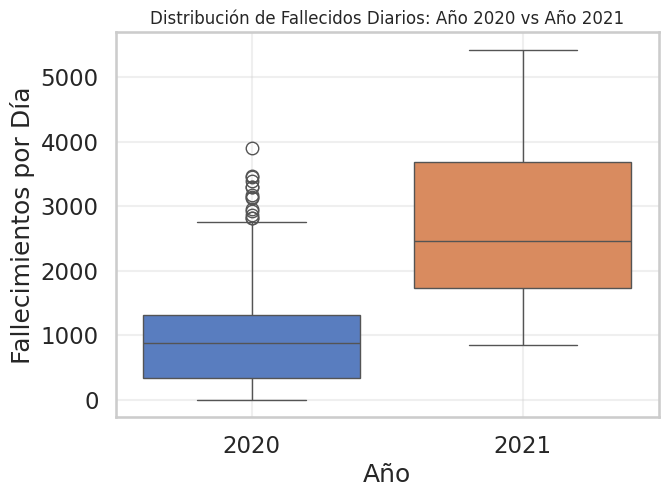

📊 ESTADÍSTICOS DESCRIPTIVOS
• Media de muertes diarias en 2020: 951.42
• Media de muertes diarias en 2021: 2702.26
• Total de días registrados en 2020: 354
• Total de días registrados en 2021: 66

⚖️ PRUEBA DE HIPÓTESIS: T-TEST DE STUDENT
• Estadístico T calculado: -12.1405
• p-valor obtenido: 1.186414e-19
--------------------------------------------------
📢 CONCLUSIÓN: Se RECHAZA la Hipótesis Nula (H0).
La diferencia entre el año 2020 y 2021 es estadísticamente SIGNIFICATIVA.
El cambio en las medias demuestra que el comportamiento del impacto del virus
cambió de manera real entre ambos periodos (vacunas, variantes, etc.).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Asegurar la columna de año extrayéndola de la fecha normalizada
df['year'] = df['date'].dt.year

# 2. Filtrar los datos para quedarnos únicamente con los años completos 2020 y 2021
df_filtrado = df[df['year'].isin([2020, 2021])].copy()

# Separar la variable de muertes diarias en los dos grupos independientes
datos_2020 = df_filtrado[df_filtrado['year'] == 2020]['deathIncrease']
datos_2021 = df_filtrado[df_filtrado['year'] == 2021]['deathIncrease']

# 3. COMPORTAMIENTO VISUAL: Crear un Boxplot comparativo (¡CORREGIDO SIN WARNINGS!)
plt.figure(figsize=(7, 5))
# Añadimos hue='year' y legend=False para cumplir con el nuevo estándar de Seaborn
sns.boxplot(data=df_filtrado, x='year', y='deathIncrease', hue='year', palette='muted', legend=False)
plt.title('Distribución de Fallecidos Diarios: Año 2020 vs Año 2021', fontsize=12)
plt.xlabel('Año')
plt.ylabel('Fallecimientos por Día')
plt.grid(True, alpha=0.3)
plt.show()

# 4. ESTADÍSTICOS DESCRIPTIVOS BÁSICOS
print("==================================================")
print("📊 ESTADÍSTICOS DESCRIPTIVOS")
print("==================================================")
print(f"• Media de muertes diarias en 2020: {datos_2020.mean():.2f}")
print(f"• Media de muertes diarias en 2021: {datos_2021.mean():.2f}")
print(f"• Total de días registrados en 2020: {len(datos_2020)}")
print(f"• Total de días registrados en 2021: {len(datos_2021)}\n")

# 5. CÁLCULO DEL T-TEST (Test de Welch: no asume varianzas iguales, ideal para salud)
t_stat, p_valor = stats.ttest_ind(datos_2020, datos_2021, equal_var=False)

print("==================================================")
print("⚖️ PRUEBA DE HIPÓTESIS: T-TEST DE STUDENT")
print("==================================================")
print(f"• Estadístico T calculado: {t_stat:.4f}")
print(f"• p-valor obtenido: {p_valor:.6e}")  # Formato científico por si es muy pequeño
print("--------------------------------------------------")

# 6. CONCLUSIÓN AUTOMÁTICA EN BASE AL ALFA ESTÁNDAR (0.05)
alfa = 0.05
if p_valor < alfa:
    print("📢 CONCLUSIÓN: Se RECHAZA la Hipótesis Nula (H0).")
    print("La diferencia entre el año 2020 y 2021 es estadísticamente SIGNIFICATIVA.")
    print("El cambio en las medias demuestra que el comportamiento del impacto del virus")
    print("cambió de manera real entre ambos periodos (vacunas, variantes, etc.).")
else:
    print("📢 CONCLUSIÓN: NO se puede rechazar la Hipótesis Nula (H0).")
    print("La diferencia observada no es estadísticamente relevante.")
    print("No hay pruebas suficientes para decir que un año fue diferente al otro.")